In [ ]:
!pip -q install gensim transformers torch scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.9 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api

print("Available models:")
#print(api.info()['models'].keys())

print("Loading pre-trained Google News embeddings...")
model = api.load("word2vec-google-news-300")

print("Vocabulary size:", len(model.key_to_index))
print("Embedding dimension:", model.vector_size)

Available models:
Loading pre-trained Google News embeddings...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Vocabulary size: 3000000
Embedding dimension: 300


## Retrieve embeddings

In [ ]:
word = "doctor"

embedding = model[word]

print("Embedding dimension:", embedding.shape)
print("\nFirst 20 values:\n")
print(embedding[:20])

Embedding dimension: (300,)

First 20 values:

[-0.09326172  0.02734375  0.07958984 -0.01287842 -0.11181641  0.3359375
 -0.13867188 -0.12011719  0.02685547 -0.20410156  0.11865234 -0.25585938
  0.0625      0.078125   -0.00150299  0.50390625  0.02355957  0.10546875
  0.04785156  0.04931641]


In [ ]:
word = "student"

embedding = model[word]

print("Embedding dimension:", embedding.shape)
print("\nFirst 20 values:\n")
print(embedding[:20])

Embedding dimension: (300,)

First 20 values:

[ 0.03686523  0.0201416   0.22167969  0.15527344  0.17871094  0.03149414
  0.31445312 -0.03369141  0.15429688 -0.375       0.05102539 -0.13183594
 -0.11962891 -0.13867188 -0.02026367  0.01318359 -0.06738281 -0.06591797
 -0.02502441 -0.140625  ]


## Similar words

In [ ]:
words = ["doctor","teacher","cricket","computer","india"]

for w in words:
    print("\nWord:", w)
    print(model.most_similar(w, topn=1))


Word: doctor
[('physician', 0.7806021571159363)]

Word: teacher
[('teachers', 0.7434303164482117)]

Word: cricket
[('cricketing', 0.8372225761413574)]

Word: computer
[('computers', 0.7979379892349243)]

Word: india
[('indian', 0.6967039704322815)]


In [ ]:
print(model.most_similar("Malayalam", topn=1))

[('Telugu', 0.7828464508056641)]


## Computing Word similarity

In [ ]:
pairs = [
    ("doctor","physician"),
    ("doctor","banana"),
    ("king","queen"),
    ("cat","dog"),
    ("india","banana")
]

for w1,w2 in pairs:
    sim = model.similarity(w1,w2)
    print(f"{w1:12s} {w2:12s} {sim:.3f}")

doctor       physician    0.781
doctor       banana       0.055
king         queen        0.651
cat          dog          0.761
india        banana       0.101


## Analogy Computation

In [ ]:
examples = [

("king","man","woman"),

("paris","france","india"),

("tokyo","japan","india"),

("walking","walk","swim"),
("boy", "boys", "girl")
]

for a,b,c in examples:

    print("\n",a,"-",b,"+",c)

    print(model.most_similar(
        positive=[a,c],
        negative=[b],
        topn=2))


 king - man + woman
[('queen', 0.7118193507194519), ('monarch', 0.6189674139022827)]

 paris - france + india
[('chennai', 0.5442505478858948), ('delhi', 0.5149926543235779)]

 tokyo - japan + india
[('hong_kong', 0.5601368546485901), ('chennai', 0.551875650882721)]

 walking - walk + swim
[('swimming', 0.8245975375175476), ('swam', 0.6806817054748535)]

 boy - boys + girl
[('teenage_girl', 0.6664935946464539), ('woman', 0.6634683012962341)]


## Visualizing Embeddings

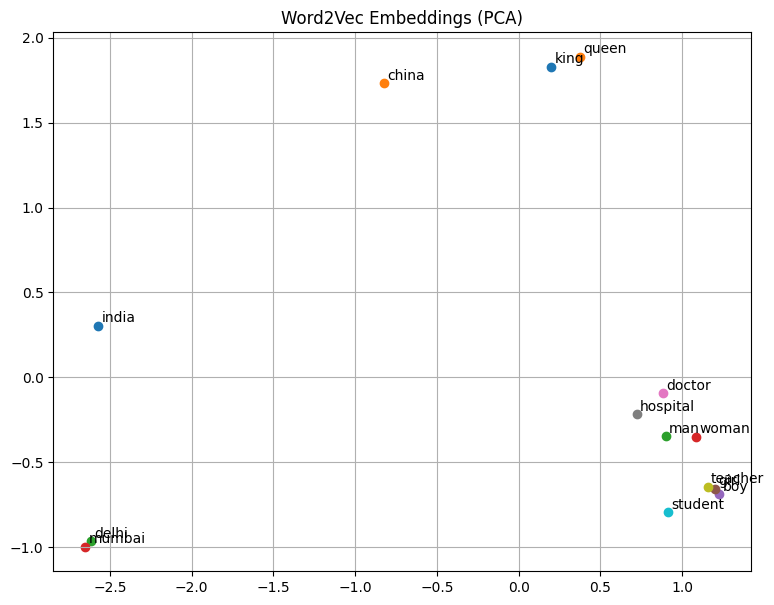

In [ ]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

words = [

"king","queen",

"man","woman",

"boy","girl",

"doctor","hospital",

"teacher","student",

"india","china",

"delhi","mumbai"

]

vectors = [model[w] for w in words]

pca = PCA(n_components=2)

points = pca.fit_transform(vectors)

plt.figure(figsize=(9,7))

for i,word in enumerate(words):

    plt.scatter(points[i,0],points[i,1])

    plt.text(points[i,0]+0.02,
             points[i,1]+0.02,
             word)

plt.title("Word2Vec Embeddings (PCA)")
plt.grid()
plt.show()

## Glove

GloVe (Global Vectors) learns word embeddings by analyzing how frequently words co-occur across the entire corpus. Words with similar co-occurrence patterns are assigned similar vector representations.

In [ ]:
model_glove = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


In [ ]:
word = "doctor"

embedding = model_glove[word]

print("Embedding dimension:", embedding.shape)
print("\nFirst 20 values:\n")
print(embedding[:20])

Embedding dimension: (100,)

First 20 values:

[ 0.043244 -0.47529   0.15808   0.20413  -0.15383   0.72284   0.26145
  0.20892  -0.3147   -0.070307 -0.43367   0.053109  0.73635   0.98111
  0.23535  -0.10449   0.50258  -0.033356 -0.35537   0.64549 ]


In [ ]:
words = ["doctor","teacher","cricket","computer","india"]

for w in words:
    print("\nWord:", w)
    print(model_glove.most_similar(w, topn=1))


Word: doctor
[('physician', 0.7673240303993225)]

Word: teacher
[('student', 0.8083398938179016)]

Word: cricket
[('rugby', 0.7827098369598389)]

Word: computer
[('computers', 0.8751984238624573)]

Word: india
[('pakistan', 0.8370323777198792)]


In [ ]:
words = ["doctor","teacher","cricket","computer","india"]

for w in words:
    print("\nWord:", w)
    print(model.most_similar(w, topn=1))


Word: doctor
[('physician', 0.7806021571159363)]

Word: teacher
[('teachers', 0.7434303164482117)]

Word: cricket
[('cricketing', 0.8372225761413574)]

Word: computer
[('computers', 0.7979379892349243)]

Word: india
[('indian', 0.6967039704322815)]


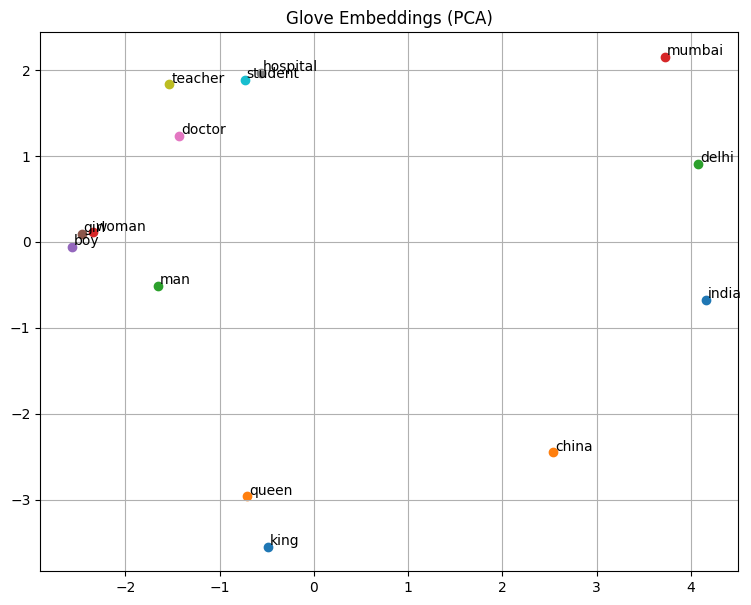

In [ ]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

words = [

"king","queen",

"man","woman",

"boy","girl",

"doctor","hospital",

"teacher","student",

"india","china",

"delhi","mumbai"

]

vectors = [model_glove[w] for w in words]

pca = PCA(n_components=2)

points = pca.fit_transform(vectors)

plt.figure(figsize=(9,7))

for i,word in enumerate(words):

    plt.scatter(points[i,0],points[i,1])

    plt.text(points[i,0]+0.02,
             points[i,1]+0.02,
             word)

plt.title("Glove Embeddings (PCA)")
plt.grid()
plt.show()

##BERT

In [ ]:
from transformers import AutoTokenizer, AutoModel

import torch

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

bert = AutoModel.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def get_embedding(sentence,target_word):

    inputs = tokenizer(sentence,
                       return_tensors="pt")

    with torch.no_grad():

        outputs = bert(**inputs)

    embeddings = outputs.last_hidden_state.squeeze()

    tokens = tokenizer.convert_ids_to_tokens(
        inputs["input_ids"][0]
    )

    index = tokens.index(target_word)

    return embeddings[index],tokens

In [ ]:
sentence1 = "I deposited money in the bank."

sentence2 = "The fisherman sat on the bank."

emb1,tokens1 = get_embedding(sentence1,"bank")

emb2,tokens2 = get_embedding(sentence2,"bank")

print(tokens1)

print(tokens2)

['[CLS]', 'i', 'deposited', 'money', 'in', 'the', 'bank', '.', '[SEP]']
['[CLS]', 'the', 'fisherman', 'sat', 'on', 'the', 'bank', '.', '[SEP]']


In [ ]:
print(emb2.shape)

torch.Size([768])


In [ ]:
cos = torch.nn.CosineSimilarity(dim=0)

print("Similarity =",
      cos(emb1,emb2).item())

Similarity = 0.45907455682754517


In [ ]:
wv = model["bank"]

print(model.similarity("bank","bank"))

1.0


In [ ]:
sentence = "The unbelievable performance amazed everyone."

tokens = tokenizer.tokenize(sentence)

print(tokens)

['the', 'unbelievable', 'performance', 'amazed', 'everyone', '.']


In [ ]:
print("Word2Vec vector size :", model.vector_size)
print("Glove vector size :", model_glove.vector_size)


print("BERT embedding size :", emb1.shape[0])

Word2Vec vector size : 300
Glove vector size : 100
BERT embedding size : 768
